<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day1/%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B81_%E1%84%86%E1%85%A5%E1%84%89%E1%85%B5%E1%86%AB%E1%84%85%E1%85%A5%E1%84%82%E1%85%B5%E1%86%BC%20%E1%84%80%E1%85%B5%E1%84%87%E1%85%A1%E1%86%AB%E1%84%8B%E1%85%B4%20%E1%84%89%E1%85%B5%E1%86%AB%E1%84%8B%E1%85%AD%E1%86%BC%E1%84%91%E1%85%A7%E1%86%BC%E1%84%80%E1%85%A1%20%E1%84%86%E1%85%A9%E1%84%83%E1%85%A6%E1%86%AF%20%E1%84%80%E1%85%A2%E1%84%87%E1%85%A1%E1%86%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 머신러닝을 활용한 신용평가 모델 개발

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from google.colab import drive
import requests

In [ ]:
import warnings
warnings.filterwarnings('ignore', module='sklearn.metrics.cluster')
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


### Data Load

In [ ]:
import gdown
import pandas as pd

file_id = "1EKTIVcSr2LUMZo9ucJJqvhCCNC7Zi68G"

url = f"https://drive.google.com/uc?id={file_id}"

output_path = "train_df_sample.pkl"
gdown.download(url, output_path, quiet=False)

df = pd.read_pickle(output_path)

Downloading...
From (original): https://drive.google.com/uc?id=1EKTIVcSr2LUMZo9ucJJqvhCCNC7Zi68G
From (redirected): https://drive.google.com/uc?id=1EKTIVcSr2LUMZo9ucJJqvhCCNC7Zi68G&confirm=t&uuid=d48cd3ea-5bc8-40b2-853d-745fea881548
To: /content/train_df_sample.pkl
100%|██████████| 334M/334M [00:03<00:00, 88.6MB/s]


### Feature Engineering

#### Dataset: Amex Prediction Default

이 데이터는 Amex prediction default 데이터를 고객 단위로 피벗한 후, 10만 개 샘플링한 데이터임.  
🔗 [Kaggle 링크](https://www.kaggle.com/competitions/amex-default-prediction)  

- Column들은 모두 정규화(normalized) & 익명화(anonymized) 되어 있음.  

##### 변수 설명  
- `D_*` = 연체(Delinquency) 변수  
- `S_*` = 소비(Spend) 변수  
- `P_*` = 결제(Payment) 변수  
- `B_*` = 잔액(Balance) 변수  
- `R_*` = 리스크(Risk) 변수

In [ ]:
df = df.reset_index()
df.head()

,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_64_count,D_64_last,D_64_nunique,D_66_count,D_66_last,D_66_nunique,D_68_count,D_68_last,D_68_nunique,target
0,f9e9fbdc82859e7fdcea35523a78f466aa40d1bb7158da...,0.419922,0.033698,0.390381,0.449951,0.390869,0.336670,0.383050,0.000727,0.680176,...,1,U,1,1,1.0,1,1,5.0,1,1
1,824526e632f8f6c497b71cb13ec0a519be76344d472970...,0.603516,0.033983,0.542480,0.651367,0.613281,0.284424,0.238159,0.004951,0.801758,...,13,U,1,0,NaN,0,13,6.0,1,0
2,b73f63bcbb43055d5bc1b0c4365efa407a939455387a25...,0.823730,NaN,0.823730,0.823730,0.823730,0.000104,NaN,0.000104,0.000104,...,0,NaN,0,0,NaN,0,0,NaN,0,0
3,783d9b5d9f6594d1a5a42d8474d328b72e8f2a5adc0a60...,0.925293,0.070185,0.702637,0.964844,0.957031,0.136353,0.149279,0.000043,0.389404,...,13,O,1,13,1.0,1,13,6.0,1,0
4,2f6a347c73f2fd188d6e110f04275bacb5e0550d7d9d6c...,0.864258,0.017011,0.826172,0.890625,0.826172,0.105286,0.137151,0.004486,0.324707,...,13,R,1,0,NaN,0,13,6.0,1,0


Hash된 ID값

- 긴 문자열은 데이터 사이즈가 클 경우 메모리 사용량에 영향 주기 때문에, 필요한 만큼만 인코딩해서 사용하는 게 좋음.  
- 이번 실습에서는 ID 열이 따로 필요하지 않지만, Hash된 값을 인코딩하는 방법을 함수로 구현해서 적용.


In [ ]:
import hashlib

def encode_customer_id(id_str):
    encoded_id = hashlib.sha256(id_str.encode('utf-8')).hexdigest()[:16]
    return encoded_id

df['customer_ID'] = df['customer_ID'].apply(encode_customer_id)

### 결측치 처리하기  

#### 결측치 비율이 높은 변수 제거  
- 결측치가 많은 변수는 분석에 방해될 수 있으므로 제거할 예정임.  
- **가정:** 이미 결측치 탐색이 끝났으며, 이 데이터의 결측치는 특별한 의미가 없다고 간주함.  
- 하지만! 실제 모델링에서는 **결측치가 왜 발생했는지 파악하는 것이 매우 중요함.**  

#### 결측치 제거 방법  
1. **함수로 구현하여 제거**  
2. **변수 선택(feature selection) 과정에서 추가 처리**  
3. **오픈소스 라이브러리 활용**  

#### 함수로 처리하는 이유  
- 코드가 깔끔하고 재사용이 가능함.  
- 실수 없이 일관되게 처리할 수 있음.  

In [ ]:
def drop_null_cols(df, threshold=0.8):
    """
    데이터프레임에서 결측치 비율이 threshold 이상인 변수를 제거하는 함수
    """
    null_percent = df.isnull().mean()
    drop_cols = list(null_percent[null_percent >= threshold].index)
    df = df.drop(drop_cols, axis=1)
    print(f"Dropped {len(drop_cols)} columns: {', '.join(drop_cols)}")
    return df

In [ ]:
df = drop_null_cols(df)

Dropped 106 columns: D_49_mean, D_49_std, D_49_min, D_49_max, D_49_last, D_73_mean, D_73_std, D_73_min, D_73_max, D_73_last, D_76_mean, D_76_std, D_76_min, D_76_max, D_76_last, R_9_mean, R_9_std, R_9_min, R_9_max, R_9_last, B_29_mean, B_29_std, B_29_min, B_29_max, B_29_last, D_87_mean, D_87_std, D_87_min, D_87_max, D_87_last, D_88_mean, D_88_std, D_88_min, D_88_max, D_88_last, D_106_mean, D_106_std, D_106_min, D_106_max, D_106_last, R_26_mean, R_26_std, R_26_min, R_26_max, R_26_last, D_108_mean, D_108_std, D_108_min, D_108_max, D_108_last, D_110_mean, D_110_std, D_110_min, D_110_max, D_110_last, D_111_mean, D_111_std, D_111_min, D_111_max, D_111_last, B_39_mean, B_39_std, B_39_min, B_39_max, B_39_last, B_42_mean, B_42_std, B_42_min, B_42_max, B_42_last, D_132_mean, D_132_std, D_132_min, D_132_max, D_132_last, D_134_mean, D_134_std, D_134_min, D_134_max, D_134_last, D_135_mean, D_135_std, D_135_min, D_135_max, D_135_last, D_136_mean, D_136_std, D_136_min, D_136_max, D_136_last, D_137_me

범주형(Categorical) 변수: 아래 `B_30` 등의 변수들은 모두 범주형 변수에 해당함.  

In [ ]:
cat_features = [
    "B_30",
    "B_38",
    "D_114",
    "D_116",
    "D_117",
    "D_120",
    "D_126",
    "D_63",
    "D_64",
    "D_68"
]
cat_features = [f"{cf}_last" for cf in cat_features]

범주형 변수와 100개의 수치형 변수를 임의로 선택.

In [ ]:
import random

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [col for col in num_cols if 'target' not in col and col not in cat_features]
num_cols_sample = random.sample([col for col in num_cols if 'target' not in col], 100)

In [ ]:
feature_list = num_cols_sample + cat_features
all_list = feature_list + ['target']

In [ ]:
df = df[all_list]

요약 테이블

In [ ]:
def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['data type'])
    summ['#missing'] = df.isnull().sum().values
    summ['%missing'] = df.isnull().sum().values / len(df)* 100
    summ['#unique'] = df.nunique().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['min'] = desc['min'].values
    summ['max'] = desc['max'].values
    summ['first value'] = df.loc[0].values
    summ['second value'] = df.loc[1].values
    summ['third value'] = df.loc[2].values

    return summ

In [ ]:
summary(df)

data shape: (100000, 111)


,data type,#missing,%missing,#unique,min,max,first value,second value,third value
D_78_max,float16,3778,3.778,1952,0.000013,10.007812,0.009781,0.509766,0.005341
R_6_mean,float16,0,0.000,8791,0.0,14.445312,0.005604,0.005291,0.003263
D_91_std,float64,4310,4.310,95300,0.0,0.747376,NaN,0.220948,NaN
D_74_last,float16,305,0.305,6472,0.0,2.714844,0.076721,0.144409,0.009087
D_141_max,float16,512,0.512,2308,0.000003,1.25293,0.896484,0.009056,NaN
...,...,...,...,...,...,...,...,...,...
D_126_last,float16,0,0.000,2,0.0,1.0,1.0,1.0,0.0
D_63_last,category,0,0.000,6,NaN,NaN,CO,CL,CO
D_64_last,category,1144,1.144,4,NaN,NaN,U,U,NaN
D_68_last,float16,1151,1.151,7,0.0,6.0,5.0,6.0,NaN


### 참고  

- 신속한 EDA 기능을 제공하는 오픈소스 라이브러리가 많음.  

- `pandas-profiling`  
  - 데이터프레임의 요약 통계 정보를 자동 생성하는 라이브러리.  
  - 기본 통계, 상관관계, 결측 데이터, 변수 분포 등을 확인할 수 있음.  

- `missingno`  
  - 결측 데이터를 시각화하여 누락된 값을 쉽게 파악할 수 있는 도구.  


- `gc.collect()`에 대해
    - `gc.collect()`는 파이썬의 **가비지 컬렉터**(Garbage Collector)를 명시적으로 호출하여 메모리를 회수하는 기능을 수행함. 가비지 컬렉터는 더 이상 사용되지 않는 객체들을 자동으로 메모리에서 해제하는 파이썬의 내장 기능임.

- `gc.collect()`를 호출하는 이유
    - **메모리 관리**  
        - 파이썬은 동적 메모리 할당 및 해제를 처리하기 때문에, 메모리 관리가 중요함.  
        - `gc.collect()`를 호출하여 더 이상 필요하지 않은 객체들을 메모리에서 제거함으로써, 메모리 사용량을 최적화할 수 있음.
    - **메모리 누수 방지**  
        - 메모리 누수란 더 이상 사용되지 않는 객체들이 메모리에 남아 있어, 메모리 사용량이 계속해서 증가하는 현상을 말함.  
        - `gc.collect()`를 호출하여 메모리에서 제거되지 않은 객체들을 강제로 회수함으로써 메모리 누수를 방지할 수 있음.
    - **성능 개선**  
        - 가비지 컬렉터는 메모리 회수에 관여하므로, 불필요한 객체들을 빠르게 회수하여 프로그램의 전반적인 성능을 향상시킬 수 있음.

- 언제 `gc.collect()`를 사용하나?
    - 파이썬 인터프리터는 자동으로 가비지 컬렉션을 수행하지만, 특정 시점에서 메모리를 즉시 회수하고자 할 때 `gc.collect()`를 사용할 수 있음.
    - 주로 **대규모 데이터 처리**나 **장기간 실행되는 프로그램**에서 메모리 사용을 최적화하기 위해 사용됨.

In [ ]:
import gc
gc.collect()

61

In [ ]:
df[cat_features].head()

,B_30_last,B_38_last,D_114_last,D_116_last,D_117_last,D_120_last,D_126_last,D_63_last,D_64_last,D_68_last
0,0.0,5.0,0.0,0.0,-1.0,1.0,1.0,CO,U,5.0
1,0.0,3.0,0.0,0.0,4.0,0.0,1.0,CL,U,6.0
2,0.0,1.0,NaN,NaN,NaN,NaN,0.0,CO,NaN,NaN
3,0.0,2.0,1.0,0.0,5.0,0.0,1.0,CO,O,6.0
4,0.0,2.0,1.0,0.0,-1.0,0.0,1.0,CL,R,6.0


In [ ]:
df[cat_features].dtypes

,0
B_30_last,float16
B_38_last,float16
D_114_last,float16
D_116_last,float16
D_117_last,float16
D_120_last,float16
D_126_last,float16
D_63_last,category
D_64_last,category
D_68_last,float16


#### 범주형 변수의 변수 타입 통일.

In [ ]:
for categorical_feature in cat_features:
    if df[categorical_feature].dtype == 'float16':
        df[categorical_feature] = df[categorical_feature].astype(str)
    if df[categorical_feature].dtype == 'category':
        df[categorical_feature] = df[categorical_feature].astype(str)
    elif df[categorical_feature].dtype == 'object':
        df[categorical_feature] = df[categorical_feature].astype(str)

In [ ]:
df[cat_features].dtypes

,0
B_30_last,object
B_38_last,object
D_114_last,object
D_116_last,object
D_117_last,object
D_120_last,object
D_126_last,object
D_63_last,object
D_64_last,object
D_68_last,object



결측치 처리 전략은 더 정밀한 데이터 분석을 통해 결정하는 것이 바람직함.  

여기서는 가장 간단한 방법을 사용하지만, 실무에서는 다양한 탐색을 거쳐 최적의 처리 전략을 선택해야 함.  


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_encoder = LabelEncoder()

for categorical_feature in cat_features:
    df[categorical_feature] = df[categorical_feature].fillna('NaN')  # Avoid inplace=True
    df[categorical_feature] = le_encoder.fit_transform(df[categorical_feature])


In [ ]:
from sklearn.impute import SimpleImputer

def impute_nan(df, num_cols, strategy='mean'):
    """
    NaN 값을 strategy에 따라 num_cols에 대해 impute하는 함수

    :param df: DataFrame
    :param num_cols: list, imputation 대상 numeric column 리스트
    :param strategy: str, imputation 전략 (default: 'mean')
    :return: DataFrame, imputed DataFrame
    """
    imputer = SimpleImputer(strategy=strategy)
    df[num_cols] = imputer.fit_transform(df[num_cols])
    return df

In [ ]:
df = impute_nan(df,num_cols_sample, strategy="mean")

In [ ]:
df.head()

,D_78_max,R_6_mean,D_91_std,D_74_last,D_141_max,B_25_std,P_4_last,R_1_max,R_13_min,B_36_last,...,B_38_last,D_114_last,D_116_last,D_117_last,D_120_last,D_126_last,D_63_last,D_64_last,D_68_last,target
0,0.009781,0.005604,0.034641,0.076721,0.896484,0.007533,0.958496,0.006855,0.000528,0.006790,...,4,0,0,0,1,1,1,3,5,1
1,0.509766,0.005291,0.220948,0.144409,0.009056,0.005058,0.008743,0.257812,0.000783,0.009422,...,2,0,0,4,0,1,0,3,6,0
2,0.005341,0.003263,0.034641,0.009087,0.179022,0.038054,0.957520,0.004131,0.008202,0.000963,...,0,2,2,7,2,0,1,4,7,0
3,0.507812,0.005215,0.253264,0.005234,0.009003,0.058553,0.005352,0.009544,0.000480,0.002556,...,1,1,0,5,0,1,1,1,6,0
4,0.009895,0.005772,0.002715,0.001693,0.008423,0.009394,0.001627,0.009415,0.002073,0.008461,...,1,1,0,0,0,1,0,2,6,0


### 데이터 시각화  

데이터를 시각적으로 파악한 후 전처리를 진행하는 것도 좋은 방법임.  
하지만 **데이터 타입이 맞지 않거나 결측치가 있으면 잘못된 시각화 정보가 나올 수** 있기 때문에, 시각화 전에 데이터 상태를 먼저 확인하는 것이 중요함.  


In [ ]:
import plotly.express as px

fig2 = px.pie(df, names='target',
             height=400, width=600,
             hole=0.7,
             title='target class Overview',
                   color_discrete_sequence=['#4c78a8', '#72b7b2'])
fig2.update_traces(hovertemplate=None, textposition='outside', textinfo='percent+label', rotation=0)
fig2.update_layout(margin=dict(t=100, b=30, l=0, r=0), showlegend=False,
                        plot_bgcolor='#fafafa', paper_bgcolor='#fafafa',
                        title_font=dict(size=20, color='#555', family="Lato, sans-serif"),
                        font=dict(size=17, color='#8a8d93'),
                        hoverlabel=dict(bgcolor="#444", font_size=13, font_family="Lato, sans-serif"))
fig2.show()

feature별 count

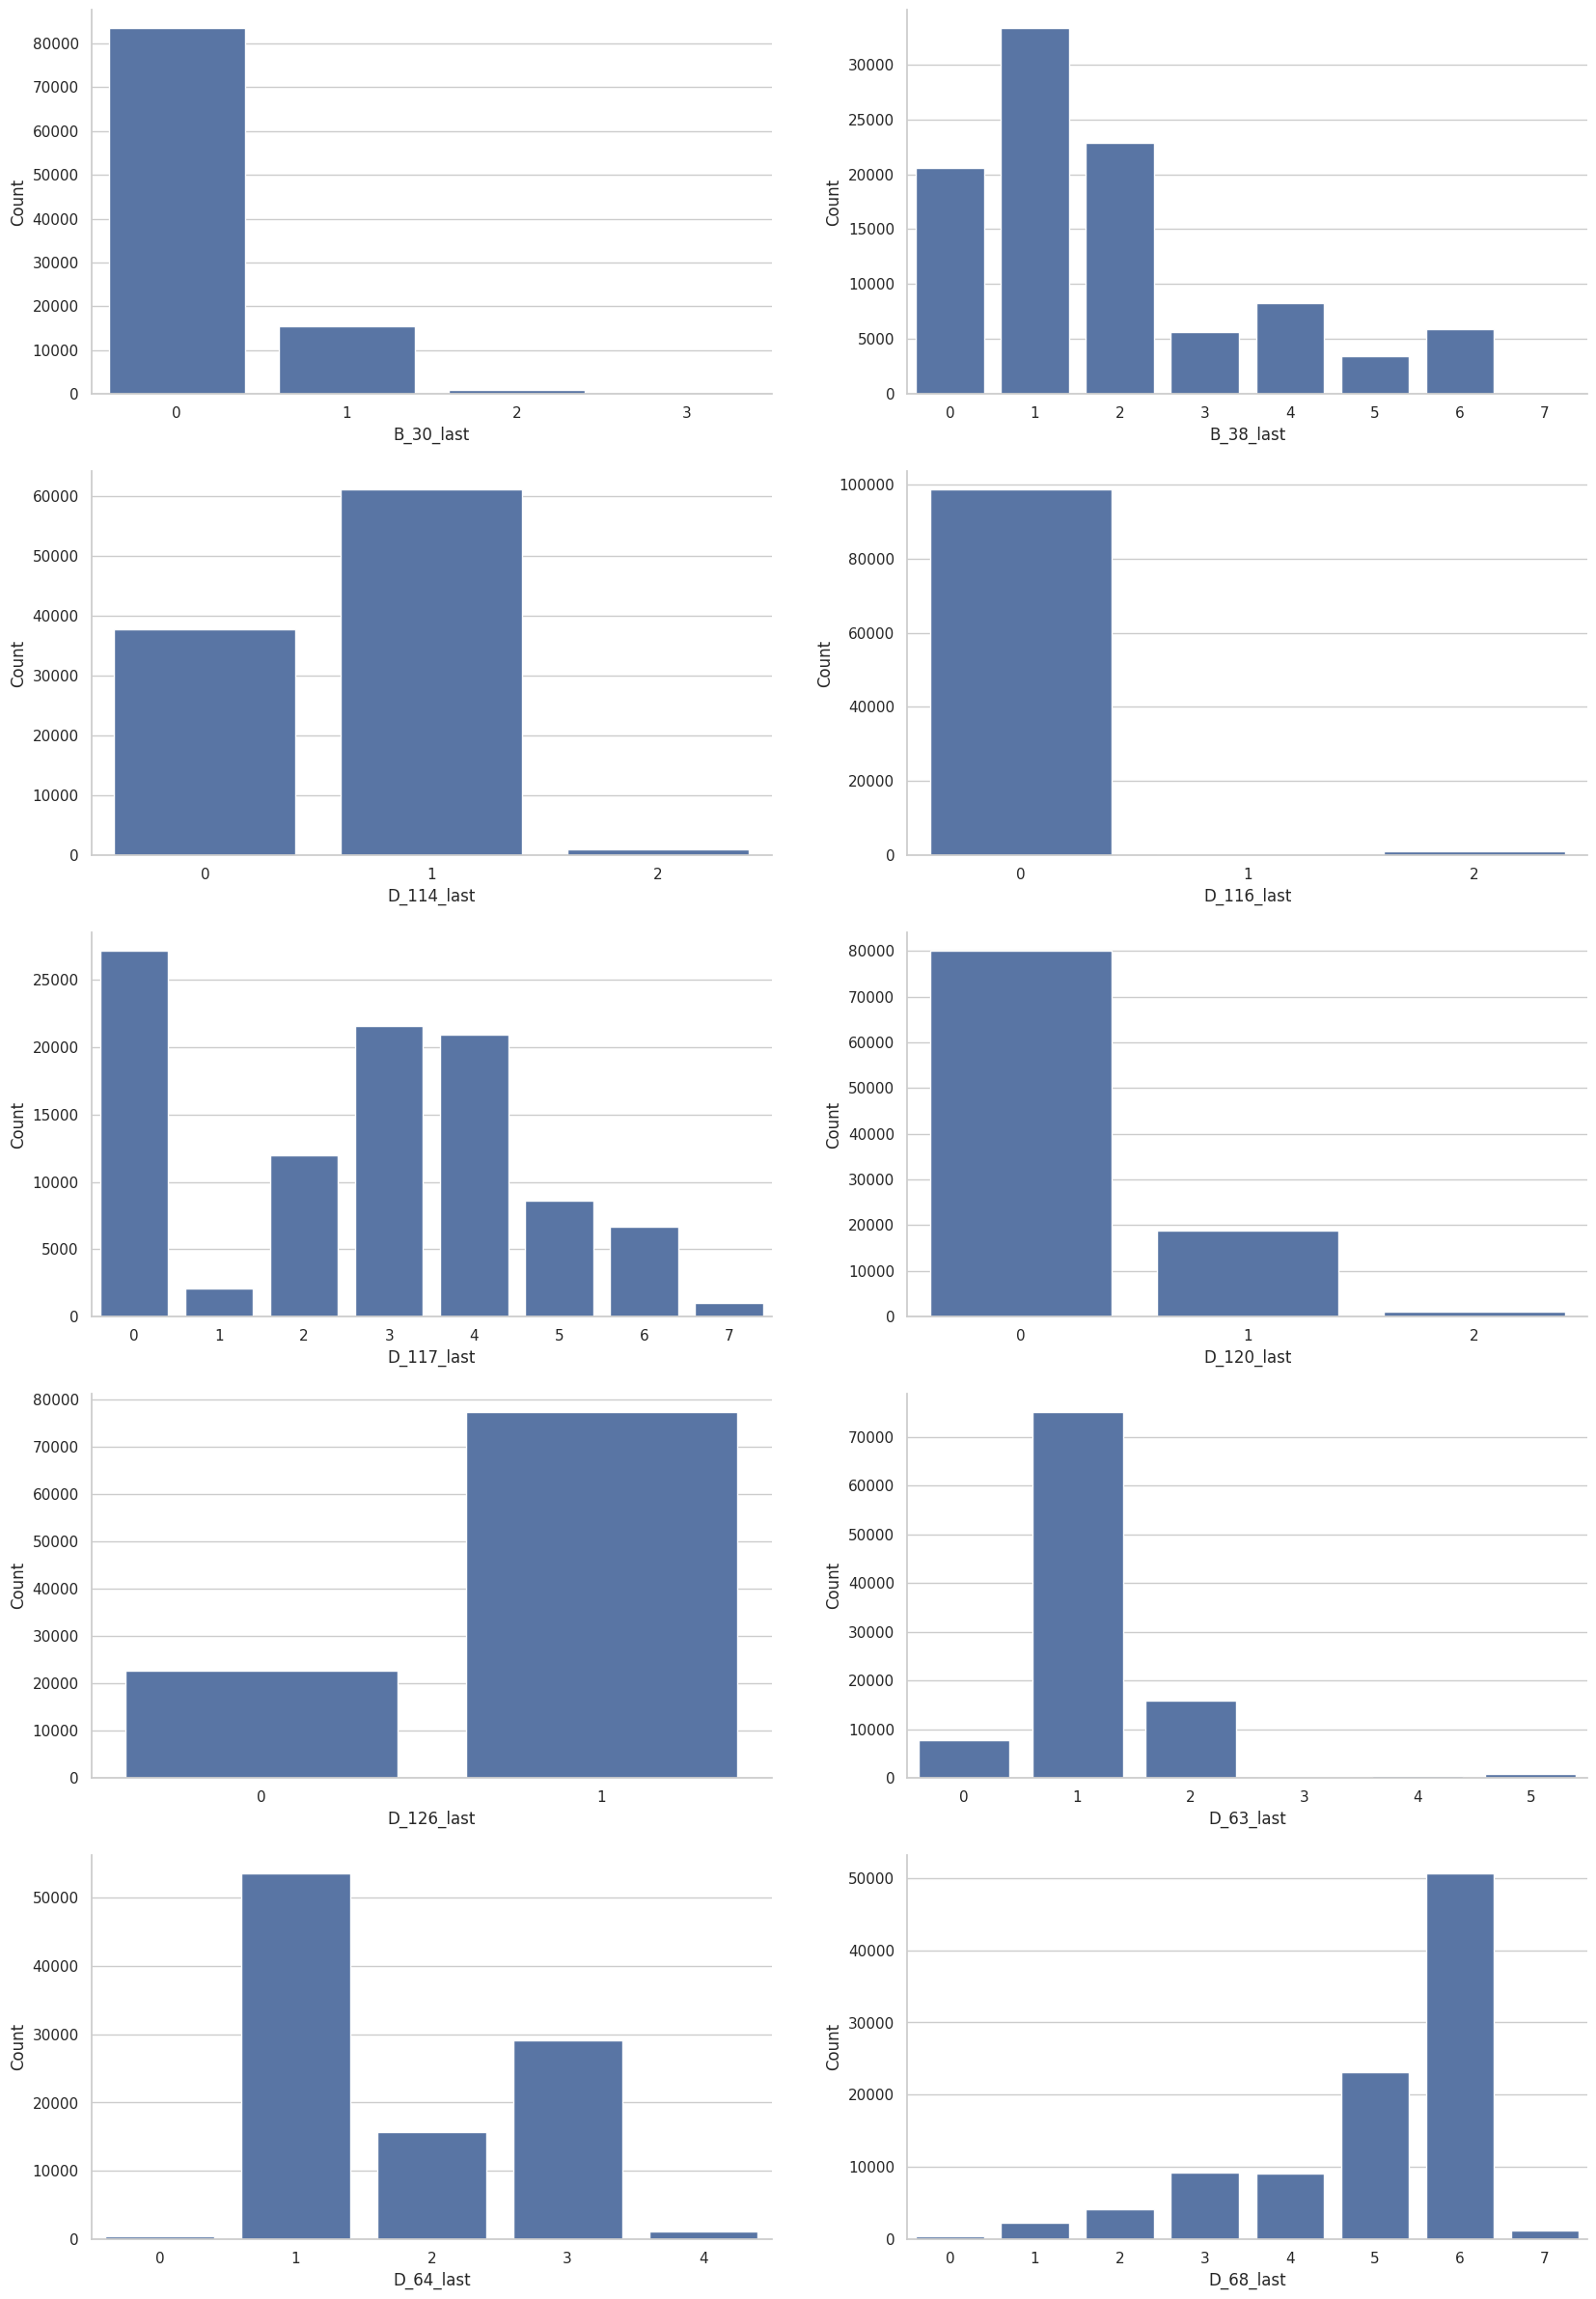

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

sns.set(style="whitegrid")
fig, axs = plt.subplots(math.ceil(len(cat_features)/2), 2, figsize=(20, 30))
for i, feature in enumerate(cat_features):
    row = i // 2
    col = i % 2
    sns.countplot(x=feature, data=df, ax=axs[row, col])
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel("Count")
    sns.despine()
plt.show()

### 변수별 시각화  

4개의 변수를 선택해 시각화 진행함.  
이를 통해 **각 변수가 타깃(0 or 1)에 따라 어떻게 분포하는지** 확인할 수 있음.  

- **각 분포가 뚜렷이 다를수록 예측력(predictive power)이 높을 가능성이 큼.**  
- 즉, 특정 변수의 값이 타깃 값에 따라 차이가 크다면, 해당 변수가 좋은 예측 변수(feature)가 될 수 있음.  

이제 분포를 확인해보자.  


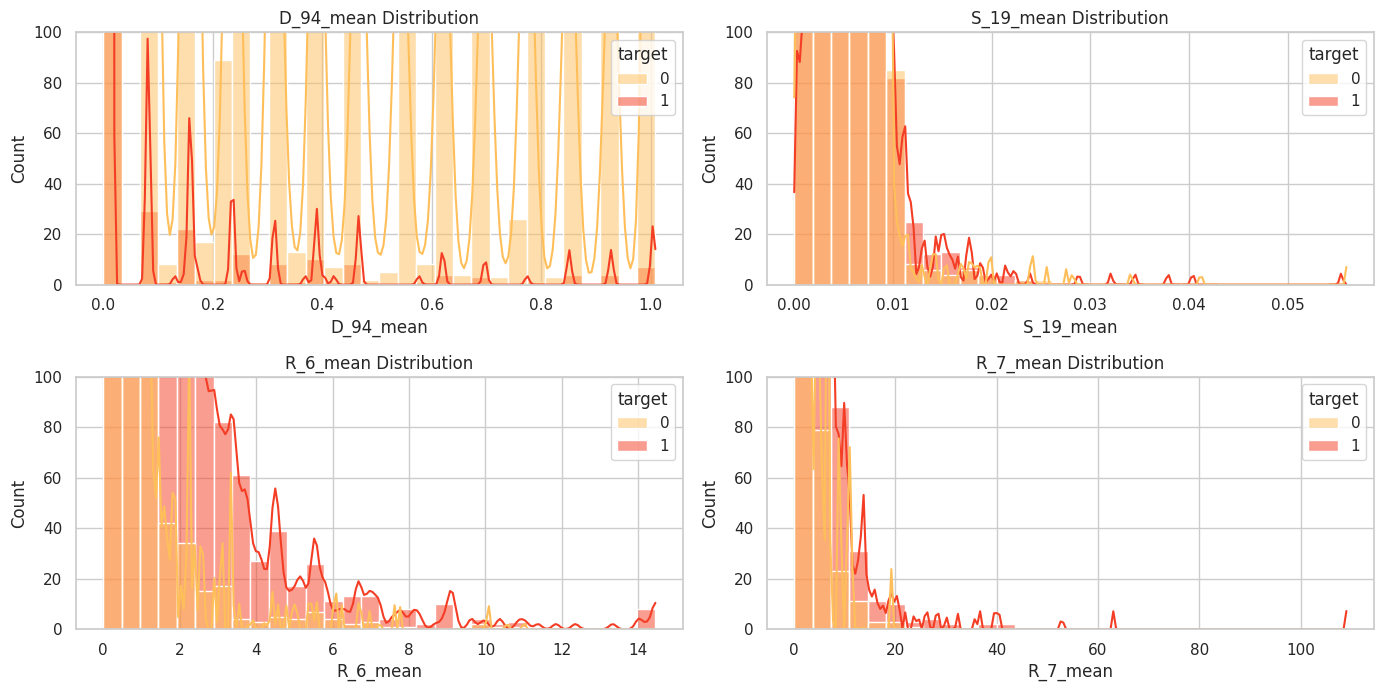

In [ ]:
exp_cols = random.sample(num_cols_sample, k=4) #임의 추출하기 때문에 코드 실행때마다 결과가 달라집니다.

plt.figure(figsize=(14,10))
for idx,column in enumerate(exp_cols):
    plt.subplot(3,2,idx+1)
    sns.histplot(x=column, hue="target", data=df,bins=30,kde=True,palette='YlOrRd')
    plt.title(f"{column} Distribution")
    plt.ylim(0,100) # ylim 조정으로 plot의 최대치를 수정할 수 있습니다.
    plt.tight_layout()

### WOE와 IV 설명

WOE(Weight of Evidence)와 IV(Information Value)는 **변수와 타깃 간의 관계를 평가하는 방법**임.  
이를 활용하면 변수의 예측력을 정량적으로 분석할 수 있음.  

#### **WOE(Weight of Evidence)**  
- **범주형 변수**가 타깃(0 or 1)과 어떻게 관련 있는지를 수치로 변환한 값.  
- 로그 오즈 비(log odds ratio)로 계산됨.  
- 특정 변수 값이 타깃에 대해 **긍정적(+)인지 부정적(-)인지**를 나타냄.  
- 값이 크거나 작을수록(양수 또는 음수) 타깃과 높은 연관성을 가짐.  
- $ WOE = \log \left( \frac{\text{Good 비율}}{\text{Bad 비율}} \right) $  
    - **Good:** 타깃 값이 0인 비율  
    - **Bad:** 타깃 값이 1인 비율  

#### **IV(Information Value)**  
- 변수의 **예측력을 수치화**한 값.  
- WOE 값을 이용해 계산되며, 특정 변수가 **타깃을 얼마나 잘 구별하는지** 평가하는 지표.  
- IV 값이 클수록 변수의 예측력이 높음.  
- $ IV = \sum (\text{Good 비율} - \text{Bad 비율}) \times WOE $  
- IV 값 해석 기준  
    - $ IV < 0.02 $ → 예측력이 거의 없음  
    - $ 0.02 \leq IV < 0.1 $ → 약한 예측력  
    - $ 0.1 \leq IV < 0.3 $ → 중간 정도의 예측력  
    - $ 0.3 \leq IV < 0.5 $ → 강한 예측력  
    - $ IV \geq 0.5 $ → 매우 강한 예측력 (하지만 과적합 가능성 있음)  

#### **EXAMPLE**
- 한 금융 기관에서 대출 연체 여부(타깃: 0 = 정상, 1 = 연체)를 예측하기 위해 `소득 수준(Income Level)` 변수를 분석한다고 가정하자.  

| Income Level | 전체 고객 수 | 연체(X=1) 수 | 정상(X=0) 수 |
|-------------|------------|-------------|-------------|
| Low         | 1000       | 400         | 600         |
| Medium      | 2000       | 300         | 1700        |
| High        | 700        | 50          | 650         |
| **합계**    | 3700       | 750         | 2950        |

각 그룹별 WOE와 IV를 계산해보자.  

---

#### 1. WOE 계산  

- 먼저, 각 그룹에서 연체(1)와 정상(0)의 비율을 구함.  

    - 전체 고객 중 **정상(0) 비율:**  
      $ P_0 = \frac{600}{2950}, \frac{1700}{2950}, \frac{650}{2950} $  
    - 전체 고객 중 **연체(1) 비율:**  
      $ P_1 = \frac{400}{750}, \frac{300}{750}, \frac{50}{750} $  


| Income Level | P(0) (정상 비율) | P(1) (연체 비율) | WOE |
|-------------|----------------|----------------|----------------|
| Low         | 0.203          | 0.533          | $\log(0.203 / 0.533) = -0.91$ |
| Medium      | 0.576          | 0.400          | $\log(0.576 / 0.400) = 0.36$  |
| High        | 0.220          | 0.067          | $\log(0.220 / 0.067) = 1.19$  |

- WOE 값이 **음수**이면 해당 그룹에서 연체(1)의 비율이 상대적으로 높고,  
**양수**이면 해당 그룹에서 정상(0)의 비율이 상대적으로 높음을 의미함.  

- 예를 들어, **Low 소득층은 연체율이 높아 WOE가 음수(-0.91)** 이고, **High 소득층은 연체율이 낮아 WOE가 양수(1.19)** 임.  

---

#### 2. IV 계산  

$
IV = \sum (\text{Good 비율} - \text{Bad 비율}) \times WOE
$

각 그룹별 계산을 수행하면:  

| Income Level | P(0) - P(1) | WOE | IV Component |
|-------------|------------|------|--------------|
| Low         | -0.330     | -0.91 | 0.3003 |
| Medium      | 0.176      | 0.36  | 0.0634 |
| High        | 0.153      | 1.19  | 0.1821 |

총 IV = 0.3003 + 0.0634 + 0.1821 = 0.5458.

---

#### 3. 해석  

**IV = 0.5458** 이므로, `Income Level` 변수는 **매우 강한 예측력(IV ≥ 0.5)을 가진 변수**임.  
즉, **소득 수준이 대출 연체 여부를 예측하는 데 중요한 변수**라고 볼 수 있음.  

---

#### 4. Summary

- WOE 값이 **양수**이면 연체 가능성이 낮음, **음수**이면 연체 가능성이 높음.  
- IV 값이 클수록 해당 변수가 타깃을 잘 구별할 수 있음.  
- 위 예제에서는 **소득 수준(Income Level)이 연체 여부 예측에 중요한 변수임**을 확인할 수 있음.  

이제 실제 데이터를 활용해 WOE와 IV를 계산해보자.  


In [ ]:
def calculate_woe_iv(df, feature_list, cat_features, target):
    result_df = pd.DataFrame(columns=['Feature', 'Bins', 'WOE', 'IV', 'IV_sum'])
    selected_features = []  # 선택된 피처들을 저장할 리스트
    bin_edges_dict = {}  # 피처별 bin 경계값을 저장할 딕셔너리
    woe_dict = {}  # 피처별 WOE 값을 저장할 딕셔너리

    for feature in feature_list:
        if feature in cat_features:  # 피처가 범주형일 경우
            df_temp = df.copy()
            df_temp[feature + '_bins'] = df_temp[feature]  # 범주형 변수의 고유값들을 bin으로 사용
            bin_edges_dict[feature] = sorted(df[feature].unique())  # 피처의 고유값들을 bin 경계값으로 저장
        else:  # 피처가 연속형일 경우
            df_temp = df.copy()
            df_temp[feature + '_bins'], bin_edges = pd.qcut(df_temp[feature], 10, duplicates='drop', retbins=True)
            bin_edges_dict[feature] = bin_edges  # 피처를 10개의 bin으로 분할하고 bin 경계값을 저장

        # 피처의 각 bin에서 이벤트와 비이벤트의 개수를 계산합니다.
        grouped_data = df_temp.groupby(feature + '_bins')[target].agg([
            ('non_event', lambda x: sum(1 - x)),  # 비이벤트(0)의 개수를 합산
            ('event', lambda x: sum(x))  # 이벤트(1)의 개수를 합산
        ]).reset_index()

        # 비이벤트와 이벤트의 비율을 계산합니다.
        grouped_data['non_event_prop'] = grouped_data['non_event'] / sum(grouped_data['non_event'])
        grouped_data['event_prop'] = grouped_data['event'] / sum(grouped_data['event'])

        # WOE(Weight of Evidence)를 계산합니다.
        grouped_data['WOE'] = np.where(
            grouped_data['event_prop'] == 0,
            0,
            np.log(grouped_data['non_event_prop'] / grouped_data['event_prop'])
        )

        # Information Value(IV)를 계산합니다.
        grouped_data['IV'] = (grouped_data['non_event_prop'] - grouped_data['event_prop']) * grouped_data['WOE']
        iv_sum = sum(grouped_data['IV'])

        if iv_sum >= 0.02:  # IV 합이 0.02 이상인 경우 피처를 선택
            selected_features.append(feature)

        result = pd.DataFrame()
        result['Feature'] = [feature] * len(grouped_data)
        result['Bins'] = grouped_data[feature + '_bins']
        result['WOE'] = grouped_data['WOE']
        result['IV'] = grouped_data['IV']
        result['IV_sum'] = [iv_sum] * len(grouped_data)

        result_df = pd.concat([result_df, result])

        woe_dict[feature] = grouped_data.set_index(feature + '_bins')['WOE'].to_dict()

    # 선택된 피처들의 개수와 목록을 출력합니다.
    print("전체 피처 개수:", len(feature_list))
    print("선택된 피처 개수:", len(selected_features))
    print("선택된 피처:", selected_features)

    return result_df, selected_features, bin_edges_dict, woe_dict



### WOE & IV 계산 함수  

이 함수는 데이터프레임(`df`), 피처 리스트(`feature_list`),  
범주형 피처 리스트(`cat_features`), 타겟 변수(`target`)을 기반으로  
**Weight of Evidence(WOE)와 Information Value(IV)** 를 계산함.  


### 계산 과정  
- 범주형 변수 (고유값을 bin으로 사용)
- 연속형 변수 (10개의 bin으로 나누고 경계값 저장)
- WOE, IV 계산  
- IV 값이 0.02 이상인 피처 선택  


### 반환 값  
- `result_df`: WOE, IV 포함 데이터프레임  
- `selected_features`: 선택된 피처 목록  
- `bin_edges_dict`: 피처별 bin 경계값  
- `woe_dict`: 피처별 WOE 값  


In [ ]:
result_df, selected_features, bin_edges_dict, woe_dict = calculate_woe_iv(df,  feature_list, cat_features, 'target')

전체 피처 개수: 110
선택된 피처 개수: 89
선택된 피처: ['D_78_max', 'R_6_mean', 'D_91_std', 'D_74_last', 'D_141_max', 'B_25_std', 'P_4_last', 'R_1_max', 'B_23_mean', 'D_52_max', 'B_26_std', 'B_10_max', 'D_125_mean', 'D_143_min', 'R_7_last', 'D_48_min', 'D_71_min', 'D_118_max', 'S_23_last', 'D_46_min', 'D_123_mean', 'D_45_min', 'D_54_last', 'S_24_std', 'B_14_max', 'D_139_last', 'D_112_min', 'D_92_std', 'R_11_max', 'D_107_mean', 'D_83_max', 'D_77_last', 'S_6_mean', 'B_18_last', 'D_129_max', 'D_133_mean', 'R_4_std', 'D_75_min', 'R_5_last', 'S_23_max', 'S_24_mean', 'D_69_last', 'D_71_last', 'R_7_mean', 'S_16_last', 'D_51_min', 'R_12_mean', 'D_104_mean', 'P_2_std', 'D_77_std', 'B_7_mean', 'D_39_last', 'D_116_count', 'D_47_mean', 'R_15_mean', 'R_25_max', 'P_3_last', 'D_59_max', 'B_8_mean', 'B_1_min', 'S_20_max', 'D_56_max', 'D_131_mean', 'B_10_std', 'S_26_last', 'B_2_std', 'D_91_max', 'B_23_min', 'D_60_std', 'B_25_min', 'B_7_last', 'B_18_min', 'B_17_last', 'D_48_last', 'D_45_last', 'R_3_min', 'D_133_last', 'R_

In [ ]:
def transform_to_woe(df, selected_features, cat_features, bin_edges_dict, woe_dict, target):
    df_woe = df[selected_features + [target]].copy()

    for feature in selected_features:
        if feature in cat_features:
            df_woe[feature] = df_woe[feature].map(woe_dict[feature])
        else:
            feature_bins = pd.cut(df_woe[feature], bins=bin_edges_dict[feature], include_lowest=True)
            df_woe[feature] = feature_bins.map(woe_dict[feature])

    return df_woe

In [ ]:
def transform_to_woe(df, selected_features, cat_features, bin_edges_dict, woe_dict, target):
    df_woe = df[selected_features + [target]].copy()

    for feature in selected_features:
        if feature in cat_features:
            # 범주형 피처의 경우, 해당 피처의 WOE 값을 매핑합니다.
            df_woe[feature] = df_woe[feature].map(woe_dict[feature])
        else:
            # 연속형 피처의 경우, bin 경계값에 따라 WOE 값을 할당합니다.
            feature_bins = pd.cut(df_woe[feature], bins=bin_edges_dict[feature], include_lowest=True)
            df_woe[feature] = feature_bins.map(woe_dict[feature])

    return df_woe


In [ ]:
df_woe = transform_to_woe(df, selected_features, cat_features, bin_edges_dict, woe_dict, 'target')

In [ ]:
df_woe.head()

,D_78_max,R_6_mean,D_91_std,D_74_last,D_141_max,B_25_std,P_4_last,R_1_max,B_23_mean,D_52_max,...,B_20_mean,B_30_last,B_38_last,D_114_last,D_117_last,D_120_last,D_63_last,D_64_last,D_68_last,target
0,0.723953,0.478272,-0.062531,0.282610,-0.611797,-0.576644,-0.990331,0.836533,-0.163304,-1.257637,...,0.195763,0.469073,-1.408741,-0.508513,-0.192825,-0.956754,-0.064498,-0.489751,-0.110150,1
1,-2.334152,0.467837,1.240996,0.282610,0.146775,-0.342885,0.187927,-0.010147,2.794054,0.521567,...,1.634596,0.469073,-0.394101,-0.508513,0.421929,0.291743,-0.249478,-0.489751,0.451170,0
2,0.275858,0.291355,-0.062531,1.858806,-0.611797,0.013378,-0.074206,0.836533,1.745737,0.521567,...,1.453144,0.469073,1.277605,-0.371257,-0.371257,-0.371257,-0.064498,-0.359813,-0.338898,0
3,-1.322385,0.467837,1.240996,1.868238,0.146775,-0.038715,0.172514,1.410614,3.123720,0.849614,...,1.453144,0.469073,1.873590,0.393672,0.751712,0.291743,-0.064498,0.474475,0.451170,0
4,0.800942,0.441620,-0.078599,1.848622,0.113618,-0.576644,0.123181,1.376227,2.794054,1.045745,...,1.786263,0.469073,1.873590,0.393672,-0.192825,0.291743,-0.249478,-0.371087,0.451170,0


### Modeling

In [ ]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

def xgboost_model(df_woe, target, folds=5, seed=2023):
    xgb_models = []  # XGBoost 모델들을 저장할 리스트
    xgb_oof = []  # out-of-fold 예측 결과를 저장할 리스트
    predictions = np.zeros(len(df_woe))  # 전체 데이터셋에 대한 예측 결과를 저장할 배열
    f_imp = []  # 특성 중요도를 저장할 리스트

    X = df_woe.drop(columns=[target])  # 독립 변수 데이터
    y = df_woe[target]  # 종속 변수 데이터

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f'{"#"*24} Training FOLD {fold+1} {"#"*24}')

        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_valid, y_valid = X.iloc[val_idx], y.iloc[val_idx]
        watchlist = [(X_train, y_train), (X_valid, y_valid)]

        model = XGBClassifier(n_estimators=1000, n_jobs=-1, max_depth=4, eta=0.2, colsample_bytree=0.67,early_stopping_rounds=300)
        model.fit(X_train, y_train, eval_set=watchlist, verbose=0)

        val_preds = model.predict_proba(X_valid)[:, 1]  # 검증 세트에 대한 예측 확률
        val_score = roc_auc_score(y_valid, val_preds)  # 검증 세트의 ROC AUC 점수
        best_iter = model.best_iteration

        idx_pred_target = np.vstack([val_idx, val_preds, y_valid]).T  # 검증 세트 인덱스, 예측 확률, 실제 타겟 값으로 구성된 배열
        f_imp.append({i: j for i, j in zip(X_train.columns, model.feature_importances_)})  # 특성 중요도 저장

        print(f'{" "*20} auc:{val_score:.5f} {" "*6} best iteration:{best_iter}')

        xgb_oof.append(idx_pred_target)  # out-of-fold 예측 결과 추가
        xgb_models.append(model)  # 학습된 모델 추가

        if val_score > 0.917:
            predictions += model.predict_proba(X)[:, 1]  # 특정 조건을 만족하는 모델의 예측 확률을 누적

    predictions /= folds  # folds 수로 나눠 평균 예측 확률 계산
    mean_val_auc = np.mean([roc_auc_score(oof[:, 2], oof[:, 1]) for oof in xgb_oof])  # 평균 out-of-fold ROC AUC 점수 계산
    print('*'*45)
    print(f'Mean AUC: {mean_val_auc:.5f}')

    return xgb_models, xgb_oof, predictions, f_imp


### XGBoost 모델 학습 관련 변수 설명  

#### 주요 변수  

- `xgb_models` : 학습된 XGBoost 모델들을 저장하는 리스트  
- `xgb_oof` : Out-of-Fold 예측 결과 리스트 (검증 인덱스, 예측 확률, 실제 타겟 값 포함)  
- `predictions` : 전체 데이터셋 예측값을 저장하는 배열 (초기값 0)  
- `f_imp` : 특성 중요도를 저장하는 리스트 (특성과 중요도 딕셔너리 형태)  

#### 데이터 관련 변수  

- `X` : 독립 변수 데이터  
- `y` : 종속 변수 데이터  
- `skf` : Stratified K-Fold 객체 (데이터 분할)  

#### Fold 별 데이터 분할  

- `fold` : 현재 Fold 번호  
- `train_idx` : 학습 데이터 인덱스  
- `val_idx` : 검증 데이터 인덱스  
- `X_train, y_train` : 학습 데이터  
- `X_valid, y_valid` : 검증 데이터  

#### 모델 학습 관련 변수  

- `watchlist` : XGBoost 학습을 위한 데이터셋  
- `model` : XGBoost 분류 모델 (하이퍼파라미터로 초기화 후 학습)  
- `val_preds` : 검증 세트 예측 확률  
- `val_score` : 검증 세트 ROC AUC 점수  
- `best_iter` : Early Stopping으로 선택된 최적 반복 횟수  

#### 최종 결과  

- `idx_pred_target` : 검증 세트 인덱스, 예측 확률, 실제 타겟 값 배열  
- `mean_val_auc` : 모든 Fold의 Out-of-Fold 예측 평균 ROC AUC 점수  

In [ ]:
df_woe.dtypes

,0
D_78_max,category
R_6_mean,category
D_91_std,float64
D_74_last,category
D_141_max,category
...,...
D_120_last,float64
D_63_last,float64
D_64_last,float64
D_68_last,float64


categorical 변수를 numeric 으로 변환

In [ ]:
def convert_category_to_numeric(df):
    for col in df.columns:
        if str(df[col].dtype) == 'category':
            df[col] = df[col].astype('int')
    return df


In [ ]:
df_woe = convert_category_to_numeric(df_woe)

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

In [ ]:
xgb_models, xgb_oof, predictions, f_imp = xgboost_model(df_woe, 'target', folds=5, seed=2023)


######################## Training FOLD 1 ########################
                     auc:0.94641        best iteration:167
######################## Training FOLD 2 ########################
                     auc:0.94616        best iteration:166
######################## Training FOLD 3 ########################
                     auc:0.94569        best iteration:108
######################## Training FOLD 4 ########################
                     auc:0.94791        best iteration:159
######################## Training FOLD 5 ########################
                     auc:0.94635        best iteration:131
*********************************************
Mean AUC: 0.94650


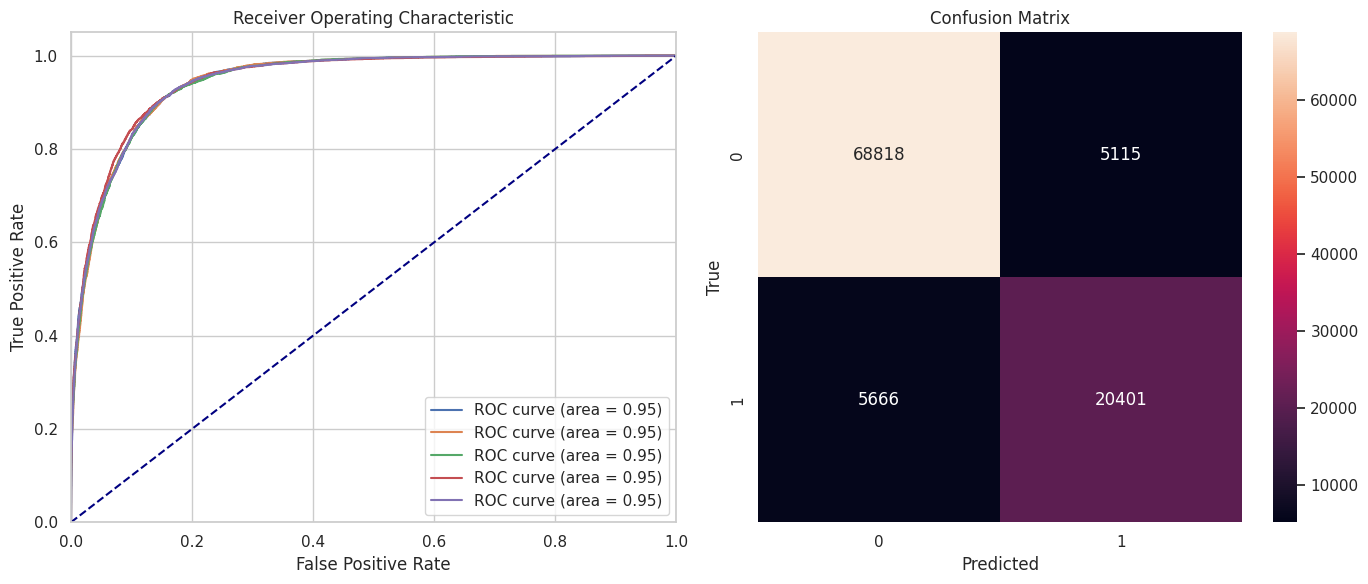

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot ROC curves
plt.subplot(1, 2, 1)
for oof in xgb_oof:
    fpr, tpr, _ = roc_curve(oof[:, 2], oof[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")

# Compute and plot confusion matrix
plt.subplot(1, 2, 2)
# 혼동 행렬(Confusion Matrix)을 계산하고 그립니다.
# 확률 대신 예측 클래스를 사용해야 합니다.
# 예측 임계값으로 0.5를 사용합니다.
predictions_class = [1 if pred > 0.5 else 0 for pred in predictions]
cm = confusion_matrix(df_woe['target'], predictions_class)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.show()



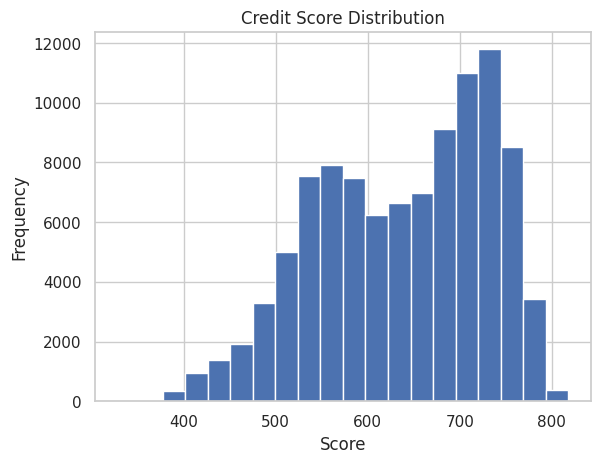

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the base score
base_score = 650

# Define the PDO (Point of double)
PDO = 20

# Calculate the factor and offset
factor = PDO / np.log(2)
offset = base_score - (factor * np.log(20))

# Define a function to calculate the score
def calculate_score(probability, factor, offset):
    odds = (probability / (1 - probability))
    score = offset + (factor * np.log(odds))
    return np.clip(score, 250, 1000)  # Clip scores between 250 and 1000

# Calculate the scores
scores = calculate_score(1 - predictions, factor, offset)

# Round the scores to the nearest integer
scores = np.round(scores)

# Plot the score distribution
plt.hist(scores, bins=20)
plt.title('Credit Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()


In [ ]:
# Add the predictions and scores to the dataframe
df_woe['probability'] = predictions
df_woe['credit_score'] = scores

# Select 5 random samples
samples = df_woe.sample(5, random_state=42)

# Display the samples
samples


,D_78_max,R_6_mean,D_91_std,D_74_last,D_141_max,B_25_std,P_4_last,R_1_max,B_23_mean,D_52_max,...,B_38_last,D_114_last,D_117_last,D_120_last,D_63_last,D_64_last,D_68_last,target,probability,credit_score
75721,0,0,-0.062531,-1,0,0,0,0,0,0,...,-0.394101,0.393672,-0.192825,0.291743,0.505683,-0.489751,-0.110150,0,0.161432,611.0
80184,-2,0,-0.081599,0,0,0,0,1,-1,0,...,-1.804870,0.393672,-0.128533,0.291743,-0.064498,-0.489751,-0.509633,1,0.477498,566.0
19864,0,0,-0.241435,0,0,0,0,1,0,0,...,1.277605,0.393672,-0.192825,0.291743,-0.064498,0.474475,-0.110150,0,0.009145,699.0
76699,0,0,-0.241435,1,0,0,0,1,2,0,...,1.873590,-0.508513,0.741034,0.291743,-0.064498,-0.489751,-0.110150,0,0.005082,716.0
92991,0,0,-0.062531,-1,0,0,0,0,0,-1,...,1.277605,-0.508513,0.421929,-0.956754,-0.064498,-0.489751,-0.714214,0,0.617690,550.0


### Inference

In [ ]:
def predict_and_score(model, instance, factor, offset):
    # Reshape the instance if it's a series/single row
    if len(instance.shape) == 1:
        instance = instance.values.reshape(1, -1)

    # Make prediction
    probability = model.predict_proba(instance)[:, 1]

    # Calculate score
    score = calculate_score(1 - probability, factor, offset)

    # Round the score to the nearest integer
    score = np.round(score)

    return score[0]


In [ ]:
inference = df_woe.drop(['target','probability','credit_score'], axis=1)

In [ ]:
inference.sample(1)

,D_78_max,R_6_mean,D_91_std,D_74_last,D_141_max,B_25_std,P_4_last,R_1_max,B_23_mean,D_52_max,...,B_1_max,B_20_mean,B_30_last,B_38_last,D_114_last,D_117_last,D_120_last,D_63_last,D_64_last,D_68_last
66300,0,0,-0.061522,0,0,0,0,1,-1,0,...,-1,-1,-1.741639,-1.80487,0.393672,-0.128533,0.291743,-0.064498,0.474475,0.45117


In [ ]:
# Extract one sample from the data
sample = inference.sample(1)

# Call the function with the first trained model and the sample data
score = predict_and_score(xgb_models[0], sample, factor, offset)
print("해당 고객의 신용 점수는 다음과 같습니다: ", score)


해당 고객의 신용 점수는 다음과 같습니다:  514.0
